In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import torch
import gc
import warnings
import joblib

warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Logistic Regression (3x Penalty + Negation) - Final Model

#### Load TF-IDF Model & Test Set

In [3]:
# Load models
tfidf = joblib.load('../models/tfidf_vectorizer.pkl')
tfidf_model = joblib.load('../models/tfidf_logreg_final.pkl')

# Load saved test set
X_test = sp.load_npz('../data/tfidf_X_test.npz')
y_test = np.load('../data/tfidf_y_test.npy')
print(f"Test size: {X_test.shape[0]:,}")

Test size: 2,261,438


## Test Set Results

In [4]:
# 14 binary labels (7 aspects x 2 sentiments)
aspect_cols = [
             'product_quality_positive', 'product_quality_negative',
             'service_positive', 'service_negative',
             'wait_time_positive', 'wait_time_negative',
             'price_value_positive', 'price_value_negative',
             'cleanliness_positive', 'cleanliness_negative',
             'atmosphere_positive', 'atmosphere_negative',
             'general_positive', 'general_negative'
             ]

# Evaluate
y_pred = tfidf_model.predict(X_test)
print("Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Test Set:")
print()
print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score (macro):    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=aspect_cols, zero_division=0))

Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Test Set:

F1 Score (weighted): 0.8817
F1 Score (macro):    0.7846

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.88      0.96      0.92    699524
product_quality_negative       0.64      0.74      0.69    170629
        service_positive       0.90      0.97      0.93    557547
        service_negative       0.71      0.80      0.75    146304
      wait_time_positive       0.82      0.91      0.86    280513
      wait_time_negative       0.64      0.75      0.69    105530
    price_value_positive       0.85      0.94      0.89    255333
    price_value_negative       0.62      0.69      0.65     79571
    cleanliness_positive       0.87      0.94      0.90    114739
    cleanliness_negative       0.68      0.64      0.66     35854
     atmosphere_positive       0.86      0.96      0.91    186086
     atmosphere_negative       0.51      0.55      

## Manually Labeled Validation Set Results

In [5]:
# Load validation set
df_val = pd.read_csv("../data/manual_absa_eval_reviews.csv")

# 14 binary labels (7 aspects x 2 sentiments)
aspect_cols = [
    'product_quality_positive', 'product_quality_negative',
    'service_positive', 'service_negative',
    'wait_time_positive', 'wait_time_negative',
    'price_value_positive', 'price_value_negative',
    'cleanliness_positive', 'cleanliness_negative',
    'atmosphere_positive', 'atmosphere_negative',
    'general_positive', 'general_negative'
]

# Predict
X = tfidf.transform(df_val["text"].fillna(""))
y_true = df_val[aspect_cols].values
y_pred = tfidf_model.predict(X)

print("Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Validation Set (Manual Labels):")
print()
print(f"F1 Score (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score (macro):    {f1_score(y_true, y_pred, average='macro'):.4f}")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=aspect_cols, zero_division=0))

Logistic Regression (Weighted Classes - 3x Penalty + Negation) - Validation Set (Manual Labels):

F1 Score (weighted): 0.5948
F1 Score (macro):    0.5636

Classification Report:
                          precision    recall  f1-score   support

product_quality_positive       0.69      0.61      0.65       708
product_quality_negative       0.53      0.59      0.56       475
        service_positive       0.71      0.71      0.71       529
        service_negative       0.80      0.68      0.74       626
      wait_time_positive       0.29      0.87      0.44       101
      wait_time_negative       0.43      0.79      0.55       180
    price_value_positive       0.48      0.75      0.59       196
    price_value_negative       0.67      0.65      0.66       298
    cleanliness_positive       0.62      0.84      0.71        76
    cleanliness_negative       0.65      0.47      0.55       127
     atmosphere_positive       0.52      0.45      0.48       216
     atmosphere_negative     

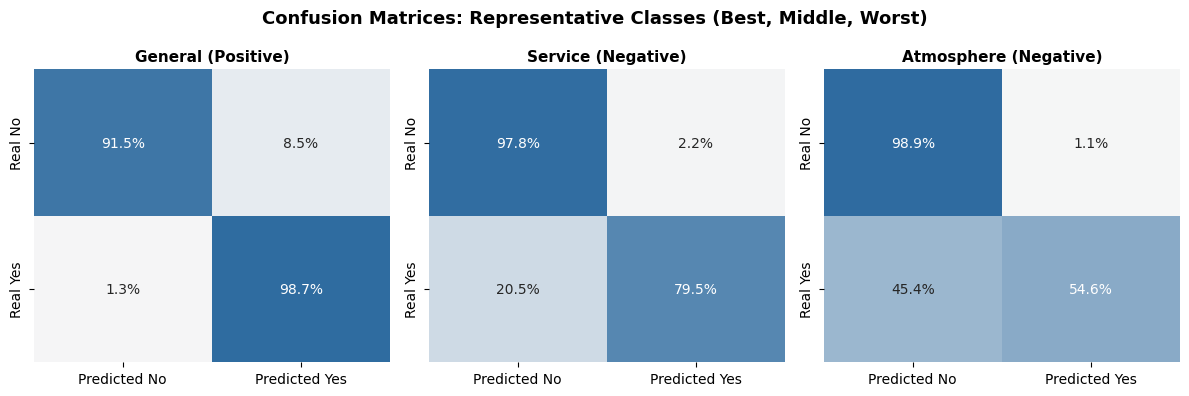

In [37]:
# Figure 2 
# Confusion Matrices

cmap = LinearSegmentedColormap.from_list('custom', ['#f7f7f7', '#2d6a9f'])

selected = ['general_positive', 'service_negative', 'atmosphere_negative']
selected_idx = [aspect_cols.index(s) for s in selected]
titles = ['General (Positive)', 'Service (Negative)', 'Atmosphere (Negative)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx, title in zip(axes, selected_idx, titles):
    tn, fp, fn, tp = mcm[idx].ravel()
    cm_data = np.array([[tn, fp], [fn, tp]])
    cm_pct = cm_data / cm_data.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', ax=ax, cmap=cmap,
                xticklabels=['Predicted No', 'Predicted Yes'],
                yticklabels=['Real No', 'Real Yes'],
                cbar=False, vmin=0, vmax=100)
    ax.set_title(title, fontsize=11, fontweight='bold')

    for text in ax.texts:
        text.set_text(text.get_text() + '%')

plt.suptitle('Confusion Matrices: Representative Classes (Best, Middle, Worst)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/figures/figure2_tfidf_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

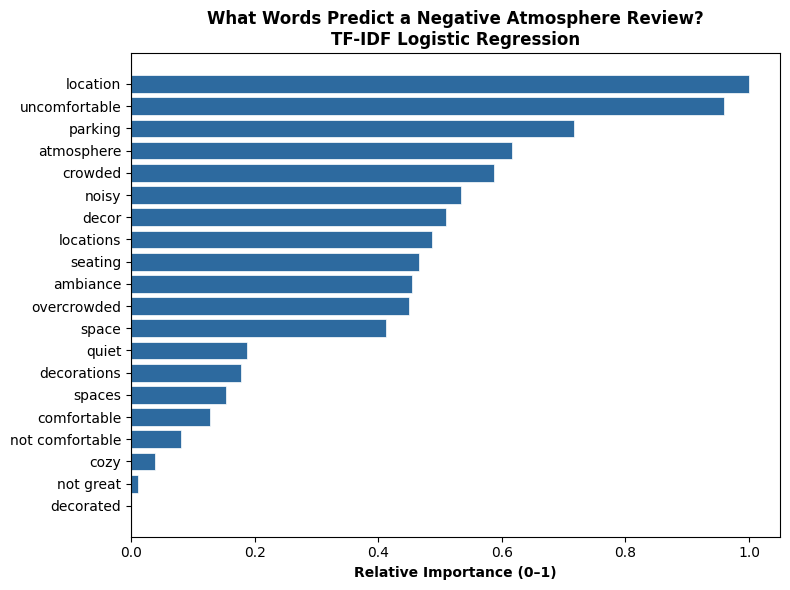

In [42]:
# Figure 3
# atmosphere_negative classifier (index 11 in aspect_cols)

atm_neg_idx = aspect_cols.index('atmosphere_negative')
atm_clf = clf_4.estimators_[atm_neg_idx]

# Get feature names from tfidf
feature_names = np.array(tfidf.get_feature_names_out())

# Get top 20 positive coefficients (words pushing towards atmosphere_negative)
coefs = atm_clf.coef_[0]
top_idx = np.argsort(coefs)[-20:][::-1]
top_words = feature_names[top_idx]
top_coefs = coefs[top_idx]

# Normalize to 0-1
top_coefs_norm = (top_coefs - top_coefs.min()) / (top_coefs.max() - top_coefs.min())


fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_words[::-1], top_coefs_norm[::-1], color='#2d6a9f', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Relative Importance (0–1)', fontweight='bold')
ax.set_title('What Words Predict a Negative Atmosphere Review?\nTF-IDF Logistic Regression', fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/figures/figure3_atmosphere_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Reviews where atmosphere_negative was predicted wrong (false negatives)
# Real = 1 (actually negative) but Predicted = 0 (missed it)

_, df_test = train_test_split(df, test_size=0.1, random_state=2)

atm_neg_idx = aspect_cols.index('atmosphere_negative')
y_pred_atm = clf_4.predict(X_test)[:, atm_neg_idx]
y_true_atm = y_test[:, atm_neg_idx]

df_test = df_test.reset_index(drop=True)
mask = (y_true_atm == 1) & (y_pred_atm == 0)

missed = df_test[mask][['text', 'rating']].sample(5, random_state=2)
print("MISSED (False Negatives):")
print(missed.to_string())

MISSED (False Negatives):
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     text  rating
87147                                                                                                                                                                                                                                                                                                       

## Why Does the Model Miss Atmosphere Negatives?

The weak supervision pipeline assigns labels using two signals:
1. **Keyword matching** — detects if an aspect is mentioned
2. **Star rating** — assigns sentiment (≤3 = negative, >3 = positive)

This creates two failure modes for atmosphere:

**1. Keywords too narrow** — descriptive language gets missed
> "covered in paperwork and receipts at 9PM" - no atmosphere keyword matched, label missed

**2. Mixed sentiment reviews** — star rating overrides sentence-level sentiment  
> "food is out of this world... service is TERRIBLE... bar covered in paperwork" (3⭐) - 
> entire review labeled negative even though food sentiment is positive

These are known limitations of weak supervision — labels are noisy proxies, 
not ground truth. 